In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sys.path.append('/home/plazas/WORK/science/satellites/satmetrics')
sys.path.append('/home/plazas/WORK/science/satellites/reca-streaks')

import line_detection_updated as ld
from photutils.background import Background2D

import image_rotation as ir
import streak_photometry

import pixelplot

Name NORAD ID Expnum Det SBAper SBFit SNR ZP SBAper SBFit
(mag/arcsec2) (mag/arcsec2) (mag) (counts/pix2) (counts/pix2)
NAVSTAR-70 39741 1134933 5 18.935 ± 0.001 18.529 ± 0.0002 4509.6 30.051 27953.08 ± 13.88 40618.31 ± 0.00
STARLINK-2600 48387 1138498 23 23.288 ± 0.020 23.210 ± 0.004 301.9 31.006 1222.30 ± 22.18 1318.33 ± 8754.95
STARLINK-2559 48298 1033925 17 24.700 ± 0.016 24.570 ± 0.028 39.5 29.450 79.47 ± 1.18 89.30 ± 16.30
STARLINK-3758 52297 1103448 4 – – 128.8 – 2464.70 ± 19.13 17.11 ± 0.11
STARLINK-3772 52290 1103448 20 – – 295.4 – 3353.62 ± 11.35 4314.00 ± 1005.76
STARLINK-3771 52293 1103448 45 – – 1326.5 – 2821.99 ± 2.13 3381.72 ± 61.02
STARLINK-3765 52295 1103448 34 – – 482.0 – 3701.93 ± 7.68 3804.10 ± 0.00
DELTA-2 R/B 20763 1072590 5 — — 1906.6 — 15950.27 ± 9.41 19719.08 ± 0.00
SORCE 27651 1125268 21 — — 35.3 — 11.10 ± 1.72 27.50 ± 13.23

In [3]:
# EXP 1103448, dets 4, 20, 45, 34

expnum = 1103448
root = "/home/plazas/DATA/starlinks_decam_2025NOV08/"

fits_files = {
    (expnum, ccd): root + "1270d649a915e6d443f525295566b298/contents"
    for ccd in [4, 20, 45, 34]
}

In [4]:
fits_files

{(1103448,
  4): '/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents',
 (1103448,
  20): '/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents',
 (1103448,
  45): '/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents',
 (1103448,
  34): '/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents'}

In [5]:
def call_photo(det, file_name):
        print ("     ")
        print ("Trying: ", expnum, det)
        hdulist = fits.open(file_name)
        print (len(hdulist))
        image_data = hdulist[det].data
        detected_lines = streak_photometry.detect_lines_hough(image_data,
                                                brightness_cuts= (3,5),
                                                thresholding_cut= 0.08)
        clustered_lines = ld.cluster(detected_lines["Cartesian Coordinates"],
                                             detected_lines["Lines"])
        rotated_images, best_fit_params = ir.complete_rotate_image(
                                                        clustered_lines=clustered_lines,
                                                        angles=detected_lines["Angles"],
                                                        image=image_data,
                                                        cart_coord=detected_lines['Cartesian Coordinates'])
        stripe = rotated_images[0]
        if expnum == 1103448 and det == 4:
            # Bad data below 500 in x
            stripe = stripe[: , 500:]
        if expnum == 1103448 and det == 20:
            # Bad data below 500 in x
            stripe = stripe[: , :1800]
        print (expnum, det, stripe.shape)
        pixelplot.pixelplot(stripe)
        streak_photometry.streak_photometry_aperture(stripe, hdu_list = hdulist)
        streak_photometry.streak_photometry_psf_fitting(stripe, hdu_list = hdulist)
    #except:
    #    pass

/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents
     
Trying:  1103448 4
62
1103448 4 (100, 1469)
Photometric zeropoint not available in image header, reporting instrumental flux only.
Regime: source-dominated
Flux (e⁻): 10407834.44
Noise background variance: 73090819.46 e⁻²
Flux error: 2660.20 ADU
SNR: 1139.0

=== Aperture Photometry Result ===
Streak center (y0): 48.25 px
Width: σ = 3.87 px, FWHM ≈ 9.11 px
Streak flux: 3029942.61 ADU ± 2660.20
Surface brightness: 2562.46 ± 2.25 counts/arcsec² [source-dominated]
SNR: 1138.99
Photometric zeropoint not available in image header, reporting instrumental flux only.
Average amp gain (e/ADU) 3.43499391856203
Average read noise (e) 6.060411
No MAGZERO keyword in header
Hola


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


length  1998.0176078256359
width 10.270686420252472
Npix 20521

=== Trail Fit Results (θ free) ===
Background: 269.80 counts/pixel
Total flux (phi): 3914172.06 ± 0.56 ADU
Trail length (L): 1977.48 px
PSF sigma: 3.42 px → FWHM = 8.06 px --> 2.12 arcsec 
Trail angle θ: -0.21 deg
Center: x0 = 758.84, y0 = 48.31
Surface brightness: 2777.78 ± 0.00 counts/arcsec²
S/N (section 3): 1386.5
Chi²: 4302522.71
Reduced Chi²: 286.3576
Image with no zero point, can't convert to magnitude
/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents
     
Trying:  1103448 20
62
1103448 20 (100, 1800)
Photometric zeropoint not available in image header, reporting instrumental flux only.
Regime: source-dominated
Flux (e⁻): 15166540.69
Noise background variance: 22927931.42 e⁻²
Flux error: 1796.82 ADU
SNR: 2457.3

=== Aperture Photometry Result ===
Streak center (y0): 47.61 px
Width: σ = 4.13 px, FWHM ≈ 9.72 px
Streak flux: 4415303.50 ADU ± 1796.82
Surface brightness: 2854.92 ± 1.1

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


length  1852.102803243299
width 11.149720691392547
Npix 20650

=== Trail Fit Results (θ free) ===
Background: 267.19 counts/pixel
Total flux (phi): 4529627.46 ± 0.00 ADU
Trail length (L): 1829.80 px
PSF sigma: 3.72 px → FWHM = 8.75 px --> 2.31 arcsec 
Trail angle θ: 0.19 deg
Center: x0 = 908.34, y0 = 47.63
Surface brightness: 3200.09 ± 0.00 counts/arcsec²
S/N (section 3): 1440.1
Chi²: 23230.73
Reduced Chi²: 1.1577
Image with no zero point, can't convert to magnitude
/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents
     
Trying:  1103448 45
62
1103448 45 (100, 2046)
Photometric zeropoint not available in image header, reporting instrumental flux only.
Regime: source-dominated
Flux (e⁻): 13584265.50
Noise background variance: 91287301.25 e⁻²
Flux error: 2981.28 ADU
SNR: 1326.5

=== Aperture Photometry Result ===
Streak center (y0): 53.23 px
Width: σ = 4.19 px, FWHM ≈ 9.87 px
Streak flux: 3954669.45 ADU ± 2981.28
Surface brightness: 2215.26 ± 1.67 coun

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


length  2079.665308353319
width 10.4236028398132
Npix 21677

=== Trail Fit Results (θ free) ===
Background: 267.26 counts/pixel
Total flux (phi): 3952527.77 ± 71410.18 ADU
Trail length (L): 2058.82 px
PSF sigma: 3.47 px → FWHM = 8.18 px --> 2.16 arcsec 
Trail angle θ: -0.20 deg
Center: x0 = 1023.84, y0 = 53.26
Surface brightness: 2654.65 ± 47.96 counts/arcsec²
S/N (section 3): 1272.3
Chi²: 36723.28
Reduced Chi²: 1.7230
Image with no zero point, can't convert to magnitude
/home/plazas/DATA/starlinks_decam_2025NOV08/1270d649a915e6d443f525295566b298/contents
     
Trying:  1103448 34
62
1103448 34 (100, 2046)
Photometric zeropoint not available in image header, reporting instrumental flux only.
Regime: background-dominated
Flux (e⁻): 15612548.57
Noise background variance: 1049185575.34 e⁻²
Flux error: 9429.75 ADU
SNR: 482.0

=== Aperture Photometry Result ===
Streak center (y0): 51.19 px
Width: σ = 3.67 px, FWHM ≈ 8.65 px
Streak flux: 4545145.91 ADU ± 9429.75
Surface brightness: 2906.02 ±

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


length  2089.5880107511216
width 10.766353380707125
Npix 22497

=== Trail Fit Results (θ free) ===
Background: 269.66 counts/pixel
Total flux (phi): 4613010.32 ± 0.15 ADU
Trail length (L): 2068.06 px
PSF sigma: 3.59 px → FWHM = 8.45 px --> 2.23 arcsec 
Trail angle θ: 0.08 deg
Center: x0 = 1028.67, y0 = 51.17
Surface brightness: 2986.22 ± 0.00 counts/arcsec²
S/N (section 3): 1419.9
Chi²: 426385.84
Reduced Chi²: 19.3592
Image with no zero point, can't convert to magnitude


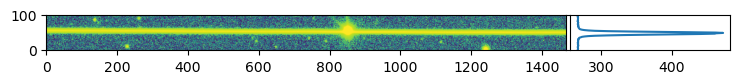

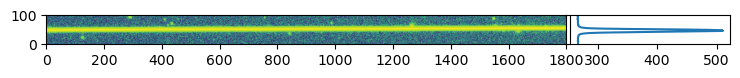

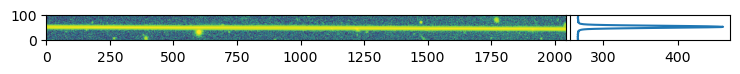

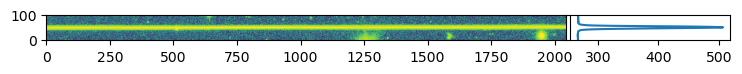

In [6]:
for det in [4, 20, 45, 34]:
    file_name = fits_files [(1103448, det)]
    print (file_name)
    call_photo(det, file_name)

In [7]:
### Try with the otehr files, in addition to expnum 1103448 above, which have different format. This is to reproduc ethe table in the paper. 

In [8]:
root = "/home/plazas/DATA/DECam-sample-streak-images/"
fits_files_others = {
    (1033925, 17): root + "2f8ef733fa7c2affc9937357519e5148/contents",
    (1134933, 5):  root + "1c1eebc352ea7660ff514d1b5df563b5/contents",
    (1138498, 23): root + "bb528e73d3221682c2d7d36246577ce5/contents",
    (1072590, 5):  root + "5b514488fd31468a5c4aa3192c597a30/contents",
    (1125268, 21): root + "ec65024afa8ab1486bf8e0f1fd676964/contents",
}

In [9]:
def call_photo_v2 (file_name, expnum, det):
        print ("     ")
        print ("Trying: ", expnum, det)
        hdulist = fits.open(file_name)
        print (len(hdulist))
        image_data = hdulist[1].data

        brightness_cuts= (2, 2) 
        thresholding_cut= (0.5)
    
        if expnum == 1033925 and det == 17:
            brightness_cuts=(3, 5)
            thresholding_cut=0.08
            
        detected_lines = streak_photometry.detect_lines_hough(image_data,
                                                brightness_cuts= brightness_cuts,
                                                thresholding_cut= thresholding_cut)
        clustered_lines = ld.cluster(detected_lines["Cartesian Coordinates"],
                                             detected_lines["Lines"])
        rotated_images, best_fit_params = ir.complete_rotate_image(
                                                        clustered_lines=clustered_lines,
                                                        angles=detected_lines["Angles"],
                                                        image=image_data,
                                                        cart_coord=detected_lines['Cartesian Coordinates'])
        stripe = rotated_images[0]
        print (expnum, det, stripe.shape)
        pixelplot.pixelplot(stripe)
        make_plots = False
        if expnum == 1134933 and det == 5:
            make_plots = True
        streak_photometry.streak_photometry_aperture(stripe, hdu_list = hdulist, make_plots = make_plots)
        streak_photometry.streak_photometry_psf_fitting(stripe, hdu_list = hdulist)

     
Trying:  1134933 5
2
1134933 5 (100, 2046)
Regime: source-dominated
Flux (e⁻): 111023375.78
Noise background variance: 2925988181.73 e⁻²
Flux error: 15666.71 ADU
SNR: 2014.6

=== Aperture Photometry Result ===
Streak center (y0): 51.82 px
Width: σ = 3.38 px, FWHM ≈ 7.95 px
Streak flux: 31562329.97 ADU ± 15666.71
Surface brightness: 21943.17 ± 10.89 counts/arcsec² [source-dominated]
SNR: 2014.61
(Using zeropoint 30.05)
Surface brightness: 19.198 ± 0.001 mag/arcsec²


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


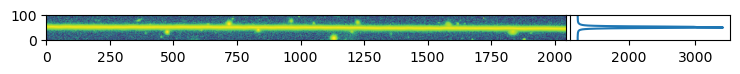

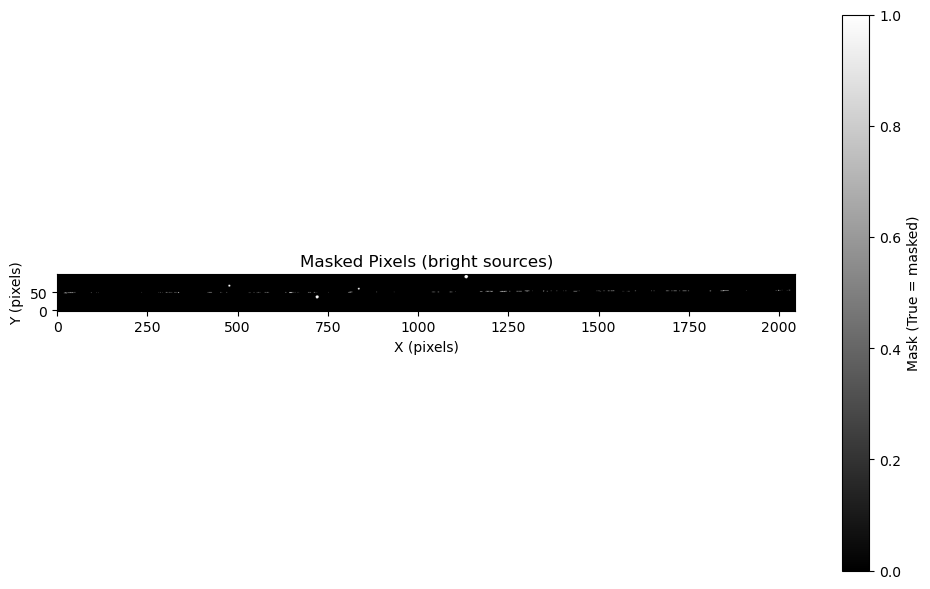

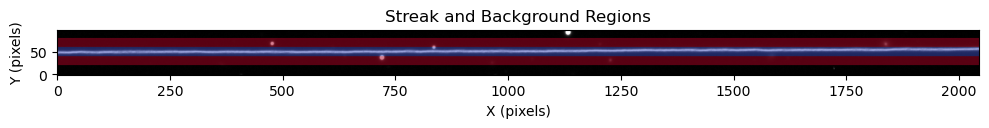

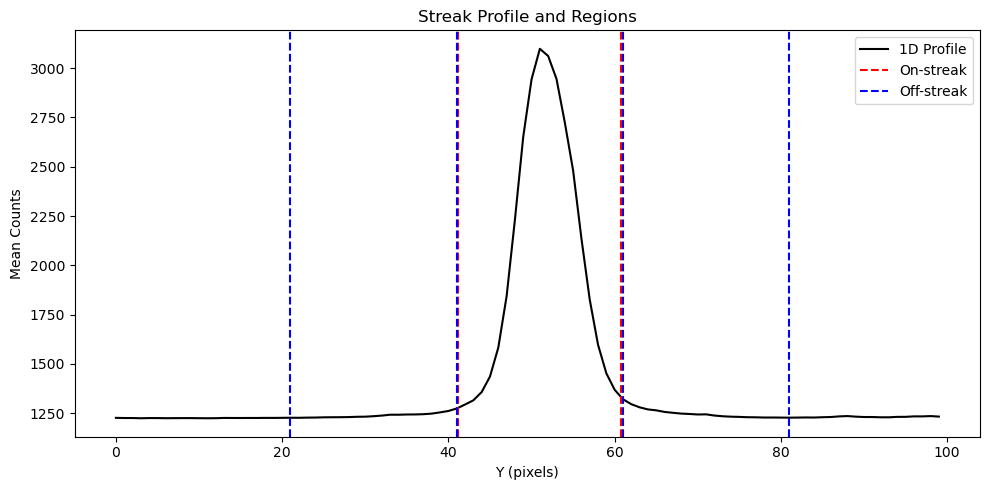

Average amp gain (e/ADU) 3.517591251445055
Average read noise (e) 6.31216
zero point [mag]:  30.051
Hola
length  2068.319255885037
width 6.942457317824897
Npix 14359

=== Trail Fit Results (θ free) ===
Background: 1243.23 counts/pixel
Total flux (phi): 31552123.41 ± 0.01 ADU
Trail length (L): 2054.43 px
PSF sigma: 2.31 px → FWHM = 5.45 px --> 1.44 arcsec 
Trail angle θ: -0.20 deg
Center: x0 = 1020.64, y0 = 51.88
Surface brightness: 31885.38 ± 0.00 counts/arcsec²
S/N (section 3): 4509.5
Chi²: 1427095.24
Reduced Chi²: 102.0082

Surface brightness (mag/arcsec²): 18.79 ± 0.0002
Signal-to-noise ratio (SNR): 4509.5
     
Trying:  1072590 5
2
1072590 5 (100, 2046)
Photometric zeropoint not available in image header, reporting instrumental flux only.
Regime: source-dominated
Flux (e⁻): 42702932.75
Noise background variance: 591950175.35 e⁻²
Flux error: 7160.92 ADU
SNR: 1695.1

=== Aperture Photometry Result ===
Streak center (y0): 51.08 px
Width: σ = 2.28 px, FWHM ≈ 5.36 px
Streak flux: 121383

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


length  2070.7669330802732
width 5.452578639084395
Npix 11291

=== Trail Fit Results (θ free) ===
Background: 2503.06 counts/pixel
Total flux (phi): 12062234.71 ± 0.01 ADU
Trail length (L): 2059.86 px
PSF sigma: 1.82 px → FWHM = 4.28 px --> 1.13 arcsec 
Trail angle θ: 0.11 deg
Center: x0 = 1026.06, y0 = 51.12
Surface brightness: 15479.47 ± 0.00 counts/arcsec²
S/N (section 3): 1906.7
Chi²: 219471.26
Reduced Chi²: 19.6624
Image with no zero point, can't convert to magnitude


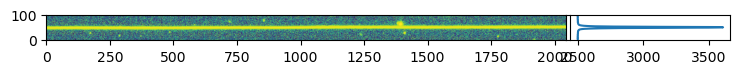

In [10]:
for key in fits_files_others:
    expnum, det = key
    if expnum != 1134933 and det != 5:
        continue
    file_name = fits_files_others[key]
    call_photo_v2 (file_name, expnum, det)

In [ ]:
        hdulist = fits.open(file_name)
        image_data = hdulist[1].data  
        detected_lines = streak_photometry.detect_lines_hough(image_data,
                                                brightness_cuts= brightness_cuts,
                                                thresholding_cut= thresholding_cut)
        clustered_lines = ld.cluster(detected_lines["Cartesian Coordinates"],
                                             detected_lines["Lines"])
        rotated_images, best_fit_params = ir.complete_rotate_image(
                                                        clustered_lines=clustered_lines,
                                                        angles=detected_lines["Angles"],
                                                        image=image_data,
                                                        cart_coord=detected_lines['Cartesian Coordinates'])
        stripe = rotated_images[0]
        streak_photometry.streak_photometry_aperture(stripe, hdu_list = hdulist, make_plots = make_plots)
        streak_photometry.streak_photometry_psf_fitting(stripe, hdu_list = hdulist